
# BlackJAX strong lens demo

Simulate a mock strong-lens image with `jax_lens`, build a PSF-aware log-likelihood, and sample the posterior with BlackJAX NUTS. Everything runs on CPU by default (no CUDA required).


In [1]:

# Keep JAX on CPU to avoid CUDA plugin warnings in minimal environments
import os
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")

import sys
sys.path.insert(0, "..")

import jax
import jax.numpy as jnp
import jax.random as jr
import jax.nn as jnn
import numpy as np
import matplotlib.pyplot as plt

import blackjax
from blackjax.adaptation.window_adaptation import window_adaptation

from jax_lens.lens.tracer import simple_tracer_image
from jax_lens.fitting.imaging import convolve_image
from jax_lens.pipeline import create_simple_lens_likelihood

jax.config.update("jax_enable_x64", True)
plt.rcParams["figure.figsize"] = (12, 4)


In [2]:

# Utilities: grid/PSF + parameter transforms (unconstrained <-> physical)

def create_grid(n_pixels: int, pixel_scale: float) -> jnp.ndarray:
    coords = jnp.linspace(-(n_pixels - 1) / 2 * pixel_scale, (n_pixels - 1) / 2 * pixel_scale, n_pixels)
    yy, xx = jnp.meshgrid(coords, coords, indexing="ij")
    return jnp.stack([yy, xx], axis=-1)

def create_psf(size: int = 13, sigma: float = 1.5) -> jnp.ndarray:
    half = (size - 1) / 2
    coords = jnp.linspace(-half, half, size)
    yy, xx = jnp.meshgrid(coords, coords, indexing="ij")
    psf = jnp.exp(-0.5 * (yy**2 + xx**2) / sigma**2)
    return psf / psf.sum()

def wrap_angle(phi: jnp.ndarray) -> jnp.ndarray:
    return (phi + jnp.pi) % (2 * jnp.pi) - jnp.pi

def softplus_pos(raw: jnp.ndarray, floor: float = 1e-3) -> jnp.ndarray:
    return floor + jnn.softplus(raw)

def inv_softplus_pos(val: jnp.ndarray, floor: float = 1e-3) -> jnp.ndarray:
    return jnp.log(jnp.expm1(jnp.maximum(val - floor, 1e-8)))

def bounded_from_raw(raw: jnp.ndarray, low: float, high: float) -> jnp.ndarray:
    return low + (high - low) * jnn.sigmoid(raw)

def raw_from_bounded(val: jnp.ndarray, low: float, high: float) -> jnp.ndarray:
    y = jnp.clip((val - low) / (high - low), 1e-6, 1 - 1e-6)
    return jnp.log(y) - jnp.log1p(-y)

def unpack_theta(theta: jnp.ndarray) -> dict:
    (
        lens_cy, lens_cx, ein_raw, q_raw, ang_raw,
        src_cy, src_cx, src_int_raw, src_re_raw, src_n_raw, src_q_raw, src_ang_raw,
    ) = theta

    params = {
        "lens_mass": {
            "centre": jnp.array([lens_cy, lens_cx]),
            "einstein_radius": softplus_pos(ein_raw, 0.01),
            "axis_ratio": bounded_from_raw(q_raw, 0.05, 0.99),
            "angle": wrap_angle(ang_raw),
        },
        "source_light": {
            "centre": jnp.array([src_cy, src_cx]),
            "intensity": softplus_pos(src_int_raw, 1e-3),
            "effective_radius": softplus_pos(src_re_raw, 1e-3),
            "sersic_index": softplus_pos(src_n_raw, 0.2),
            "axis_ratio": bounded_from_raw(src_q_raw, 0.2, 0.99),
            "angle": wrap_angle(src_ang_raw),
        },
    }
    return params

def pack_params(params: dict) -> jnp.ndarray:
    lens = params["lens_mass"]
    src = params["source_light"]
    return jnp.array([
        lens["centre"][0],
        lens["centre"][1],
        inv_softplus_pos(lens["einstein_radius"], 0.01),
        raw_from_bounded(lens["axis_ratio"], 0.05, 0.99),
        lens["angle"],
        src["centre"][0],
        src["centre"][1],
        inv_softplus_pos(src["intensity"], 1e-3),
        inv_softplus_pos(src["effective_radius"], 1e-3),
        inv_softplus_pos(src["sersic_index"], 0.2),
        raw_from_bounded(src["axis_ratio"], 0.2, 0.99),
        src["angle"],
    ])


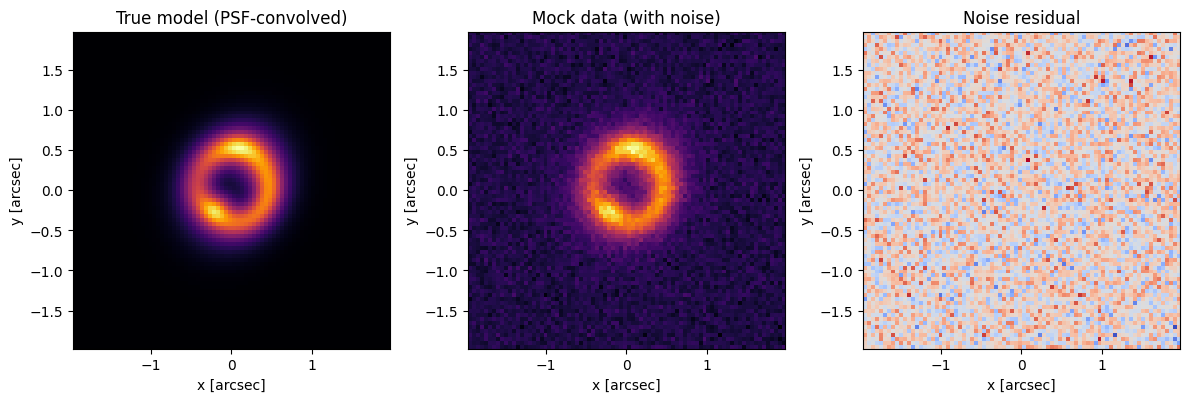

In [4]:

# Simulate mock data (lensed image + PSF + Gaussian noise)

n_pixels = 80
pixel_scale = 0.05  # arcsec / pixel

grid = create_grid(n_pixels, pixel_scale)
grid_flat = grid.reshape(-1, 2)

true_params = {
    "lens_mass": {
        "centre": jnp.array([0.0, 0.0]),
        "einstein_radius": 1.05,
        "axis_ratio": 0.82,
        "angle": 0.5,
    },
    "source_light": {
        "centre": jnp.array([0.08, 0.04]),
        "intensity": 1.2,
        "effective_radius": 0.3,
        "sersic_index": 1.2,
        "axis_ratio": 0.7,
        "angle": 1.0,
    },
}

psf = create_psf(size=13, sigma=1.5)

true_image = simple_tracer_image(
    grid=grid_flat,
    lens_mass_params=true_params["lens_mass"],
    source_light_params=true_params["source_light"],
    lens_mass_type="sie",
    source_light_type="sersic",
).reshape(n_pixels, n_pixels)
true_image = convolve_image(true_image, psf, padding="edge")

noise_sigma = 0.2
noise_map = jnp.ones_like(true_image) * noise_sigma
rng = np.random.default_rng(0)
data = np.array(true_image) + rng.normal(0.0, noise_sigma, true_image.shape)
data = jnp.array(data)

theta_true = pack_params(true_params)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
extent = (
    -(n_pixels - 1) / 2 * pixel_scale,
    (n_pixels - 1) / 2 * pixel_scale,
    -(n_pixels - 1) / 2 * pixel_scale,
    (n_pixels - 1) / 2 * pixel_scale,
)
axes[0].imshow(np.array(true_image), origin="lower", extent=extent, cmap="inferno")
axes[0].set_title("True model (PSF-convolved)")
axes[1].imshow(np.array(data), origin="lower", extent=extent, cmap="inferno")
axes[1].set_title("Mock data (with noise)")
axes[2].imshow(np.array(data - true_image), origin="lower", extent=extent, cmap="coolwarm")
axes[2].set_title("Noise residual")
for ax in axes:
    ax.set_xlabel("x [arcsec]")
    ax.set_ylabel("y [arcsec]")
plt.tight_layout()


In [5]:

# Build log-likelihood (PSF-aware) and a simple Gaussian prior in unconstrained space

likelihood_fn = create_simple_lens_likelihood(
    grid=grid_flat,
    data=data.flatten(),
    noise_map=noise_map.flatten(),
    z_lens=0.5,
    z_source=1.0,
    lens_mass_type="sie",
    source_light_type="sersic",
    psf=psf,
    image_shape=(n_pixels, n_pixels),
)
likelihood_fn = jax.jit(likelihood_fn)

prior_loc = theta_true
prior_scale = jnp.array([0.1, 0.1, 0.3, 0.5, 0.5, 0.1, 0.1, 0.5, 0.3, 0.3, 0.5, 0.5])

@jax.jit
def log_prior(theta: jnp.ndarray) -> jnp.ndarray:
    z = (theta - prior_loc) / prior_scale
    return -0.5 * jnp.sum(z**2) - jnp.sum(jnp.log(prior_scale * jnp.sqrt(2 * jnp.pi)))

@jax.jit
def log_posterior(theta: jnp.ndarray) -> jnp.ndarray:
    params = unpack_theta(theta)
    return likelihood_fn(params) + log_prior(theta)

# Quick sanity check: log-posterior near truth
log_posterior(theta_true)


Array(1252.02401002, dtype=float64)

In [6]:

# Run NUTS with dual-averaging / mass-matrix adaptation

rng = jr.PRNGKey(10)
rng, rng_init, rng_adapt, rng_sample = jr.split(rng, 4)

init_theta = theta_true + 0.1 * jr.normal(rng_init, theta_true.shape)

adapt = window_adaptation(
    blackjax.nuts,
    log_posterior,
    initial_step_size=0.02,
    target_acceptance_rate=0.8,
    is_mass_matrix_diagonal=True,
)
adapt_results, adapt_info = adapt.run(rng_adapt, init_theta, num_steps=500)

nuts = blackjax.nuts.differentiable(
    log_posterior,
    **adapt_results.parameters,
)

@jax.jit
def one_step(state, key):
    new_state, info = nuts.step(key, state)
    return new_state, (new_state, info)

num_samples = 500
keys = jr.split(rng_sample, num_samples)
state, (states, infos) = jax.lax.scan(one_step, adapt_results.state, keys)

samples = states.position  # shape (num_samples, ndim)


In [8]:

# Summarise posterior means / stds on the physical parameters
burn_in = 100
posterior_tree = jax.vmap(unpack_theta)(samples[burn_in:])

mean_params = jax.tree.map(lambda x: jnp.mean(x, axis=0), posterior_tree)
std_params = jax.tree.map(lambda x: jnp.std(x, axis=0), posterior_tree)

print("Einstein radius: {:.3f} ± {:.3f}".format(
    float(mean_params["lens_mass"]["einstein_radius"]),
    float(std_params["lens_mass"]["einstein_radius"]),
))
print("Lens axis ratio: {:.3f} ± {:.3f}".format(
    float(mean_params["lens_mass"]["axis_ratio"]),
    float(std_params["lens_mass"]["axis_ratio"]),
))
print("Source centre (y, x):", np.round(np.array(mean_params["source_light"]["centre"]), 3))
print("Source effective_radius: {:.3f} ± {:.3f}".format(
    float(mean_params["source_light"]["effective_radius"]),
    float(std_params["source_light"]["effective_radius"]),
))
print("Sersic index: {:.3f} ± {:.3f}".format(
    float(mean_params["source_light"]["sersic_index"]),
    float(std_params["source_light"]["sersic_index"]),
))


Einstein radius: 1.050 ± 0.002
Lens axis ratio: 0.823 ± 0.005
Source centre (y, x): [0.079 0.039]
Source effective_radius: 0.295 ± 0.005
Sersic index: 1.190 ± 0.023
